# Setup

In [1]:
!pip install mujoco gymnasium matplotlib imageio numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 13.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
os.environ["MUJOCO_GL"] = "egl"

import mujoco
import numpy as np
import matplotlib.pyplot as plt

os.chdir("/content/drive/MyDrive/visual-policy-learning/envs/panda")

# Load Panda Simulation

In [4]:
MODEL_PATH = "scene.xml"
model = mujoco.MjModel.from_xml_path(MODEL_PATH)
data = mujoco.MjData(model)

print("Controls (model.nu):", model.nu)

Controls (model.nu): 8


In [5]:
for i in range(100):
    mujoco.mj_step(model, data)

print("Simulation running ✔")

Simulation running ✔


# Apply Action

In [6]:
action = np.random.uniform(-1, 1, size=model.nu)

data.ctrl[:] = action
mujoco.mj_step(model, data)

# Camera

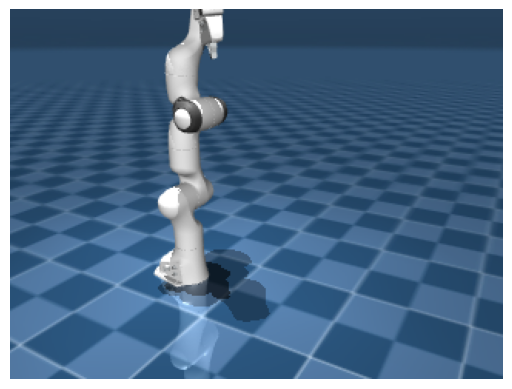

In [7]:
renderer = mujoco.Renderer(model)

renderer.update_scene(data)

img = renderer.render()

plt.imshow(img)
plt.axis("off")
plt.show()

In [8]:
ee_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "hand")

ee_pos = data.xpos[ee_id]

print("End effector:", ee_pos)

End effector: [ 1.28688043e-01 -6.08803775e-06  9.42501558e-01]


In [9]:
target = np.array([0.5, 0.0, 0.4])

# Reward

In [10]:
dist = np.linalg.norm(ee_pos - target)
reward = -dist

print("Distance:", dist)
print("Reward:", reward)

Distance: 0.6574043731402454
Reward: -0.6574043731402454


# Playground

In [11]:
os.chdir("/content/drive/MyDrive/visual-policy-learning")
import importlib

import envs.panda_reach_env
importlib.reload(envs.panda_reach_env)

<module 'envs.panda_reach_env' from '/content/drive/MyDrive/visual-policy-learning/envs/panda_reach_env.py'>

In [12]:
from envs.panda_reach_env import PandaReachEnv

env = PandaReachEnv(
    render_mode=True,
    image_width=64,
    image_height=64,
    physics_steps=4,
)
obs, info = env.reset()
print(info)
print("image mean/std:", obs["image"].mean(), obs["image"].std())



========== MODEL INFO ==========
nu: 8
nv: 9

Actuators:
0: actuator1
1: actuator2
2: actuator3
3: actuator4
4: actuator5
5: actuator6
6: actuator7
7: actuator8

Actuator ctrl ranges:
[[-2.8973e+00  2.8973e+00]
 [-1.7628e+00  1.7628e+00]
 [-2.8973e+00  2.8973e+00]
 [-3.0718e+00 -6.9800e-02]
 [-2.8973e+00  2.8973e+00]
 [-1.7500e-02  3.7525e+00]
 [-2.8973e+00  2.8973e+00]
 [ 0.0000e+00  2.5500e+02]]

{'ee_pos': array([0.088, 0.   , 0.926], dtype=float32), 'target_pos': array([ 0.5807964 , -0.05194154,  0.33008513], dtype=float32), 'distance': 0.775023078678083, 'success': False}


In [13]:
for i in range(200):

    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    print(i, reward, info["distance"], "img_mean", obs["image"].mean())

    if terminated:
        print("SUCCESS")
        break

    if truncated:
        print("TRUNCATED")
        break

env.close()


0 -0.8656017631368204 0.7754342044613839
1 -0.8323407881803004 0.7763093261596878
2 -0.8569294773671315 0.7764988319501075
3 -0.8431878654494636 0.7758096391865211
4 -0.843695363135577 0.7748806822224804
5 -0.8281811081252305 0.7747964912903297
6 -0.8128150837409527 0.7754085880808149
7 -0.8191724352783847 0.7762781013629297
8 -0.8355158427430328 0.7766936348336475
9 -0.837580498585483 0.776988198801965
10 -0.8224900343336484 0.7769816336659121
11 -0.8254556513918653 0.7767291223644741
12 -0.7995285652003656 0.7776148550563587
13 -0.8378388626866848 0.7791950190825379
14 -0.8259502917410718 0.7803350442036142
15 -0.8388252080394145 0.7799293151890391
16 -0.8268479493947801 0.7793225134292007
17 -0.8141366341337322 0.7799077729493881
18 -0.8036622420450235 0.7803867822869223
19 -0.8334390550216113 0.780599764573127
20 -0.82633384574313 0.7811741658185355
21 -0.849204571667986 0.7815570949071933
22 -0.8233131539529849 0.782120977411042
23 -0.8268736606615337 0.7818906750091711
24 -0.8811